# 02 — El grafo AMI de los 150 medidores

**Entregable:** validación visual de `services/monitor-gsp`, paso 7.
**Decisiones que ilustra:** `docs/decisions/ADR-003-construccion-del-grafo-ami.md`.

Continúa `01_gsp_hello_world.ipynb` (E6), que validó la pipeline
`A → L → L_norm → eigh → GFT` sobre un grafo de juguete de 10 nodos. Acá el
mismo aparato corre sobre los **150 medidores reales** de `ami_meters`, y cada
figura muestra una de las decisiones del ADR-003 con los datos que la
sostienen.

## Qué NO hace este notebook

**No reimplementa nada.** Todo sale de `urbia_monitor_gsp`, el módulo instalado,
y de `experiments/difuminador-tau/run.py`, el script de medición. El notebook
sólo dibuja. Si una cifra de acá no coincide con `RESULTADOS.md` o con los tests
de regresión, el que está mal es el notebook.

La señal sintética y los codos de τ se importan del experimento en vez de
recalcularse, para que las figuras muestren **literalmente** los números de
`experiments/difuminador-tau/RESULTADOS.md` y no una segunda realización que
casi coincide.

## Sustrato

`data/topologies/manizales_150.json` (`manizales-v1`), la instantánea versionada
de `ami_meters` exportada el 2026-08-07. No se consulta PostgreSQL ni el broker
MQTT: el notebook se reproduce sin acceso al cluster.

## Instalación del kernel

```bash
cd ~/urbIA-unal/notebooks
python3.12 -m venv .venv && source .venv/bin/activate
pip install -r requirements.txt
pip install -e ../services/monitor-gsp     # el núcleo sólo depende de numpy
```

## Sección 0 — Preparación

### Sobre los colores de las figuras

Las seis zonas llevan **color fijo** en todo el notebook: el color identifica a
la zona y no a su posición en un ranking, así que una figura que reordene las
zonas no repinta a nadie.

Un detalle medido, porque cambia el diseño de las figuras: **seis colores
categóricos no alcanzan para distinguir seis series que compartan una misma
región de dibujo.** Validado con los seis tonos de abajo bajo el criterio
*all-pairs* (el que corresponde a un diagrama de dispersión, donde el lector
tiene que emparejar cada punto con su color de la leyenda), la peor pareja da
ΔE 7,2 en simulación de protanopia contra un piso de 8, y ΔE 13,2 en visión
normal contra un piso de 15. Ningún subconjunto de seis del conjunto de
referencia lo pasa; cinco sí.

La consecuencia práctica: **las zonas se dibujan en paneles separados**, y
cuando comparten panel el nombre de la zona va como título o como etiqueta
directa. El color nunca es el único canal que porta la identidad.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap

# Raíz del repositorio: se busca hacia arriba el archivo de topología, así el
# notebook corre igual desde notebooks/ que desde la raíz.
REPO = next(
    p
    for p in [Path.cwd(), *Path.cwd().parents]
    if (p / "data" / "topologies" / "manizales_150.json").exists()
)
TOPOLOGY = REPO / "data" / "topologies" / "manizales_150.json"
FIGURES = REPO / "notebooks" / "figures"
FIGURES.mkdir(exist_ok=True)

# El módulo instalado. Nada de esto se reimplementa acá.
from urbia_monitor_gsp.graph import (
    DEFAULT_TAU,
    GraphConfig,
    MeterNode,
    ZeroDegreeNodeError,
    band_cut_index,
    band_energy,
    build_ami_graph,
    build_zone_graph,
    degenerate_groups,
    diffuse,
    dirichlet_energy,
    gft,
    local_frame,
    low_pass_response,
    pairwise_distances_m,
)

# El script de medición, para reutilizar su señal sintética y sus codos.
sys.path.insert(0, str(REPO / "experiments" / "difuminador-tau"))
import run as exp  # noqa: E402

print("topología ", TOPOLOGY.relative_to(REPO))
print("figuras   ", FIGURES.relative_to(REPO))
print("señal     ", f"base {exp.BASELINE_KWH} kWh + N(0, {exp.NOISE_STD_KWH})"
      f" + pico {exp.SPIKE_KWH} kWh, semilla {exp.SEED}")

topología  data/topologies/manizales_150.json
figuras    notebooks/figures
señal      base 10.0 kWh + N(0, 0.3) + pico 5.0 kWh, semilla 20260807


In [2]:
# ── Paleta y cromo de las figuras ────────────────────────────────────────────
SURFACE, INK, INK_2, MUTED = "#fcfcfb", "#0b0b0b", "#52514e", "#898781"
GRID, AXIS, NEUTRAL = "#e1e0d9", "#c3c2b7", "#f0efec"

# Color por zona, en orden fijo. Identidad, no ranking.
ZONE_COLOR = {
    "centro": "#2a78d6",
    "chipre": "#eb6834",
    "la_enea": "#1baf7a",
    "palermo": "#eda100",
    "palogrande": "#e87ba4",
    "universitario": "#008300",
}
ANTES, DESPUES = "#2a78d6", "#eb6834"   # par validado para 2 series

# Rampa secuencial de un solo tono, para magnitud continua.
BLUE_RAMP = [
    "#cde2fb", "#b7d3f6", "#9ec5f4", "#86b6ef", "#6da7ec", "#5598e7",
    "#3987e5", "#2a78d6", "#256abf", "#1c5cab", "#184f95", "#104281", "#0d366b",
]
SEQ = LinearSegmentedColormap.from_list("urbia_blue", BLUE_RAMP)
SEQ.set_bad(NEUTRAL)

mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE, "savefig.dpi": 150, "savefig.bbox": "tight",
    "figure.dpi": 110,
    "axes.edgecolor": AXIS, "axes.linewidth": 0.9,
    "axes.labelcolor": INK_2, "axes.titlecolor": INK, "text.color": INK,
    "axes.titlesize": 11, "axes.titleweight": "bold", "axes.labelsize": 9.5,
    "axes.grid": True, "axes.axisbelow": True,
    "axes.spines.top": False, "axes.spines.right": False,
    "grid.color": GRID, "grid.linewidth": 0.8,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "xtick.labelcolor": INK_2, "ytick.labelcolor": INK_2, "xtick.labelsize": 9,
    "ytick.labelsize": 9, "font.size": 10,
    "legend.frameon": False, "legend.fontsize": 9,
})


def guardar(fig, nombre: str) -> None:
    """Guarda la figura en notebooks/figures/ para el documento LaTeX."""
    destino = FIGURES / f"02_{nombre}.png"
    fig.savefig(destino)
    print(f"figura guardada: {destino.relative_to(REPO)}")


_ESQUINAS = {
    "upper left": (0.02, 0.98, "left", "top"),
    "upper right": (0.98, 0.98, "right", "top"),
    "lower left": (0.02, 0.02, "left", "bottom"),
    "lower right": (0.98, 0.02, "right", "bottom"),
}


def anotar(ax, texto: str, loc: str = "upper left") -> None:
    """Caja de anotación con las cifras medidas del panel."""
    x, y, ha, va = _ESQUINAS[loc]
    ax.text(
        x, y, texto, transform=ax.transAxes, ha=ha, va=va, fontsize=8.2,
        color=INK_2, linespacing=1.5,
        bbox=dict(facecolor=SURFACE, edgecolor=GRID, boxstyle="round,pad=0.4"),
    )


def pie_de_panel(ax, texto: str, dy: float = -0.26) -> None:
    """Cifras del panel, escritas por fuera de los ejes.

    Una caja dentro de los ejes tapa datos; con veinte a treinta nodos por
    zona no queda esquina libre. Va debajo.
    """
    ax.text(0.5, dy, texto, transform=ax.transAxes, ha="center", va="top",
            fontsize=8.2, color=INK_2, linespacing=1.6)


def num(valor: float, dec: int = 2) -> str:
    """Formatea con coma decimal, que es la convención del documento."""
    return f"{valor:.{dec}f}".replace(".", ",")

In [3]:
# ── Carga y construcción ─────────────────────────────────────────────────────
meters = exp.load_topology(TOPOLOGY)
config = GraphConfig()                      # k-NN k=4, unión, pesos binarios
grafo = build_ami_graph(meters, config)
ZONAS = grafo.zone_order

# Señal sintética del experimento, una por zona, con el pico ya inyectado.
signals = {z: exp.build_signal(grafo.zones[z], i) for i, z in enumerate(ZONAS)}

print(f"medidores  {grafo.n_meters} en {grafo.n_zones} zonas")
print(f"config     k-NN k={config.k} {config.knn_mode}, pesos {config.weighting},"
      f" puente inter-zona {config.inter_zone_bridge}")
print(f"aristas    {sum(z.stats.n_edges for z in grafo.zones.values())}\n")

resumen = pd.DataFrame([
    {
        "zona": z,
        "n": grafo.zones[z].n_meters,
        "aristas": grafo.zones[z].stats.n_edges,
        "grado min": grafo.zones[z].stats.degree_min,
        "grado max": grafo.zones[z].stats.degree_max,
        "componentes": grafo.zones[z].stats.n_components,
        "Fiedler": round(grafo.zones[z].stats.lambda_1, 4),
        "lambda max": round(float(grafo.zones[z].eigenvalues[-1]), 4),
        "arista max (m)": round(grafo.zones[z].stats.max_edge_length_m, 1),
        "pico en": signals[z].spike_device_id,
    }
    for z in ZONAS
]).set_index("zona")
resumen

medidores  150 en 6 zonas
config     k-NN k=4 union, pesos binary, puente inter-zona False
aristas    369



,n,aristas,grado min,grado max,componentes,Fiedler,lambda max,arista max (m),pico en
zona,,,,,,,,,
centro,25,65,4.0,8.0,1,0.0545,1.5795,460.4,urbia-cen-mon-0003
chipre,25,62,4.0,7.0,1,0.0505,1.5570,344.2,urbia-chi-mon-0022
la_enea,25,61,4.0,9.0,1,0.0901,1.5512,490.5,urbia-ena-tri-0023
palermo,25,61,4.0,7.0,1,0.0940,1.5037,469.4,urbia-pal-tri-0018
palogrande,30,72,4.0,7.0,1,0.0602,1.6004,425.3,urbia-pgr-mon-0001
universitario,20,48,4.0,7.0,1,0.1238,1.5058,500.9,urbia-uni-tri-0015


---

## Sección 1 — Los 150 medidores sobre sus coordenadas reales

### Figura 1 — qué muestra

Dos vistas del mismo conjunto de medidores.

El **panel superior** ubica los 150 medidores en el plano local en kilómetros,
todos del mismo color, con cada agrupación etiquetada con su nombre de zona y su
conteo. Responde a la pregunta de escala: cuán separadas están las zonas entre
sí y cuán grande es cada una. Las etiquetas —no el color— son las que identifican
a cada zona.

Los **seis paneles inferiores** dan cada zona por separado, en su color fijo y en
metros respecto de su propio baricentro, para poder ver la distribución interna
que el panel superior comprime. Cada panel lleva las dimensiones del *bounding
box* de su zona y su densidad.

figura guardada: notebooks/figures/02_fig1_medidores.png


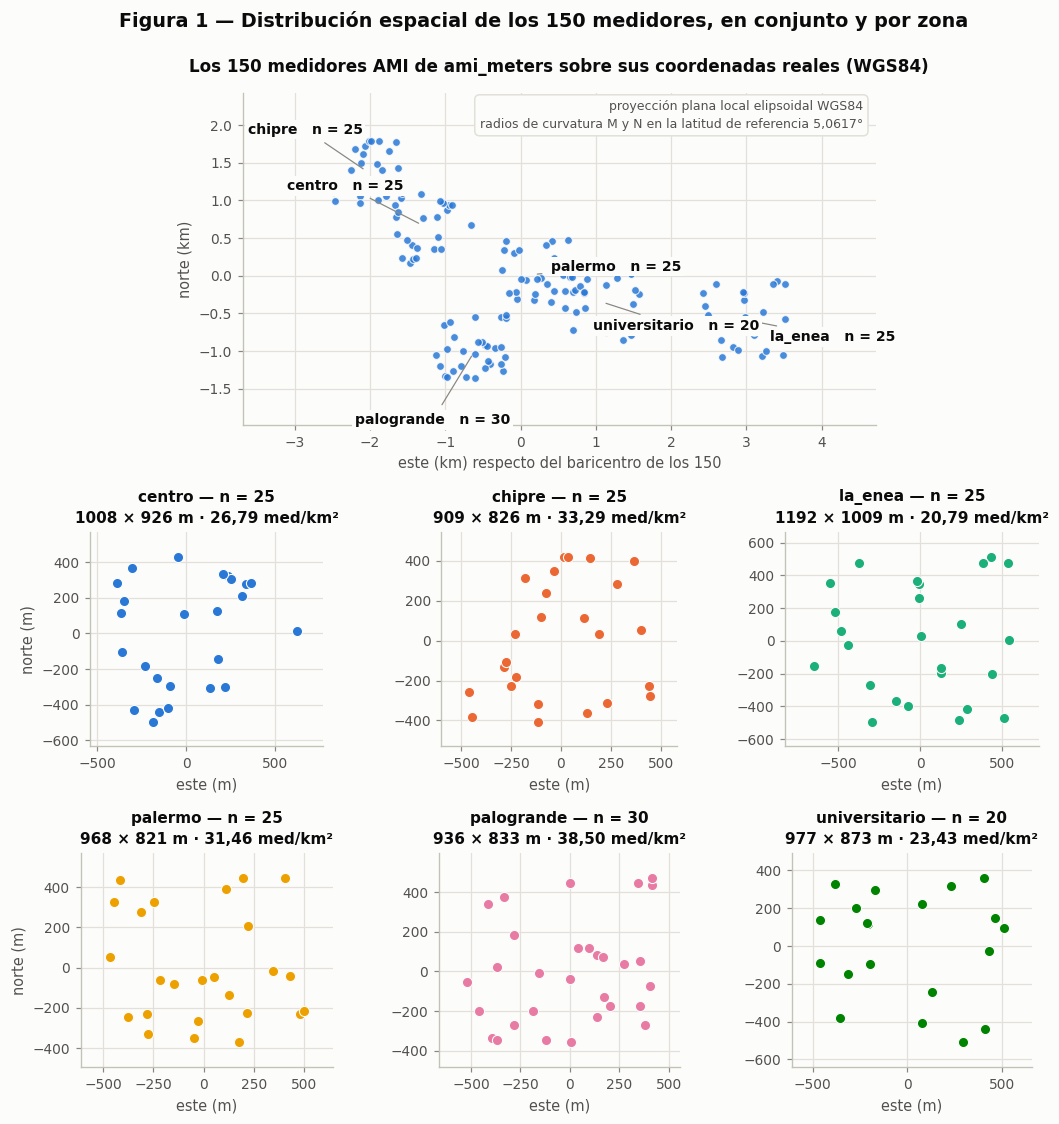

In [4]:
# ── Figura 1: los 150 medidores ──────────────────────────────────────────────
lats_g = np.array([m.lat for m in meters])
lons_g = np.array([m.lon for m in meters])
frame_g = local_frame(lats_g, lons_g)

coords_zona, densidad_zona, bbox_zona = {}, {}, {}
for z in ZONAS:
    de_zona = [m for m in meters if m.zona == z]
    lats = np.array([m.lat for m in de_zona])
    lons = np.array([m.lon for m in de_zona])
    coords_zona[z] = frame_g.project(lats, lons) / 1000.0          # km, marco global
    local = grafo.zones[z].coords_m                                # m, marco zonal
    ancho = float(local[:, 0].max() - local[:, 0].min())
    alto = float(local[:, 1].max() - local[:, 1].min())
    bbox_zona[z] = (ancho, alto)
    densidad_zona[z] = len(de_zona) / (ancho * alto / 1e6)

fig = plt.figure(figsize=(11.5, 11.5))
gs = fig.add_gridspec(3, 3, height_ratios=[1.55, 1, 1], hspace=0.42, wspace=0.28)

# Panel superior: los 150 en un solo color, zonas identificadas por etiqueta.
ax = fig.add_subplot(gs[0, :])
todos = np.vstack([coords_zona[z] for z in ZONAS])
ax.scatter(todos[:, 0], todos[:, 1], s=26, color=ANTES, alpha=0.85,
           edgecolor=SURFACE, linewidth=0.7, zorder=3)
# Las etiquetas se empujan radialmente hacia afuera del baricentro global y se
# atan a su agrupación con una línea guía: las zonas se solapan en proyección y
# una etiqueta puesta encima de cada nube choca con la vecina.
centro_global = todos.mean(axis=0)
for z in ZONAS:
    c = coords_zona[z]
    cen = c.mean(axis=0)
    direccion = cen - centro_global
    direccion = direccion / (np.linalg.norm(direccion) or 1.0)
    radio = np.abs(c - cen).max() + 0.55
    ax.annotate(
        f"{z}   n = {len(c)}",
        xy=cen, xytext=cen + direccion * radio,
        ha="center", va="center", fontsize=9.2, color=INK, weight="bold",
        bbox=dict(facecolor=SURFACE, edgecolor="none", pad=1.8),
        arrowprops=dict(arrowstyle="-", color=MUTED, linewidth=0.8,
                        shrinkA=4, shrinkB=4),
    )
ax.set_aspect("equal")
ax.set_xlabel("este (km) respecto del baricentro de los 150")
ax.set_ylabel("norte (km)")
ax.set_title("Los 150 medidores AMI de ami_meters sobre sus coordenadas reales (WGS84)",
             pad=14)
ax.margins(0.20)
anotar(ax, "proyección plana local elipsoidal WGS84\nradios de curvatura M y N "
           f"en la latitud de referencia {num(frame_g.lat0_deg, 4)}°",
       loc="upper right")

# Paneles inferiores: una zona por panel, en su color.
for i, z in enumerate(ZONAS):
    axz = fig.add_subplot(gs[1 + i // 3, i % 3])
    local = grafo.zones[z].coords_m
    centro = local - local.mean(axis=0)
    axz.scatter(centro[:, 0], centro[:, 1], s=44, color=ZONE_COLOR[z],
                edgecolor=SURFACE, linewidth=0.7, zorder=3)
    axz.set_aspect("equal")
    ancho, alto = bbox_zona[z]
    axz.set_title(
        f"{z} — n = {grafo.zones[z].n_meters}\n"
        f"{ancho:.0f} × {alto:.0f} m · {num(densidad_zona[z])} med/km²",
        color=INK, fontsize=10, linespacing=1.5,
    )
    axz.set_xlabel("este (m)")
    if i % 3 == 0:
        axz.set_ylabel("norte (m)")
    axz.margins(0.15)

fig.suptitle("Figura 1 — Distribución espacial de los 150 medidores, en conjunto y por zona",
             fontsize=12.5, weight="bold", y=0.945)
guardar(fig, "fig1_medidores")
plt.show()

In [5]:
# Cifras del panel superior que la conclusión cita.
import itertools

cent = {z: coords_zona[z].mean(axis=0) for z in ZONAS}
filas = []
for a, b in itertools.combinations(ZONAS, 2):
    d_cent = float(np.linalg.norm(cent[a] - cent[b]) * 1000)
    ca, cb = coords_zona[a] * 1000, coords_zona[b] * 1000
    d_min = float(np.sqrt(((ca[:, None, :] - cb[None, :, :]) ** 2).sum(2)).min())
    filas.append({"par": f"{a} – {b}", "centroides (m)": round(d_cent),
                  "medidores más próximos (m)": round(d_min)})
pares = pd.DataFrame(filas).sort_values("medidores más próximos (m)").reset_index(drop=True)

diametros = {z: float(pairwise_distances_m(grafo.zones[z].coords_m).max()) for z in ZONAS}
print(f"diámetro zonal      {min(diametros.values()):.0f} a {max(diametros.values()):.0f} m")
print(f"arista k=4 más larga {max(z.stats.max_edge_length_m for z in grafo.zones.values()):.0f} m")
print(f"pares de zonas con medidores a menos de 500 m: "
      f"{int((pares['medidores más próximos (m)'] < 500).sum())} de {len(pares)}\n")
pares

diámetro zonal      1044 a 1348 m
arista k=4 más larga 501 m
pares de zonas con medidores a menos de 500 m: 3 de 15



,par,centroides (m),medidores más próximos (m)
0,palermo – universitario,911,25
1,centro – chipre,1030,73
2,palermo – palogrande,1317,261
3,centro – palermo,1635,517
4,palogrande – universitario,1792,795
5,la_enea – universitario,1930,849
6,centro – palogrande,1792,937
7,centro – universitario,2546,1506
8,chipre – palermo,2623,1528
9,la_enea – palermo,2816,1694


### Figura 1 — qué se concluye

**Las zonas están separadas, pero no uniformemente, y la diferencia importa.**
Los centroides zonales distan entre 911 m (palermo – universitario) y 5 368 m
(chipre – la_enea), con diámetros zonales de 1 044 a 1 348 m. Para doce de los
quince pares ningún medidor de una zona tiene vecinos de otra a menos de 500 m,
y como la arista intra-zona más larga del grafo con k=4 mide 501 m, la partición
zonal no le quita a esos pares ninguna arista que la proximidad hubiera
propuesto.

**Para tres pares sí.** palermo – universitario tienen dos medidores a **25 m**,
centro – chipre a 73 m, palermo – palogrande a 261 m. La partición por zona
**no es una partición geográfica**: es la administrativa que trae la columna
`zona`, y en esos tres pares corta a través de proximidad física real. La
Sección 3 mide cuántas aristas cuesta.

**La densidad varía por un factor 1,85** entre la zona más rala (la_enea, 20,79
med/km²) y la más densa (palogrande, 38,50 med/km²). Ese solo hecho ya anticipa
que ningún radio único de vecindad va a servir a las seis zonas, que es lo que
la Sección 3 confirma.

---

## Sección 2 — El grafo construido con k = 4

### Figura 2 — qué muestra

El grafo que efectivamente analiza el monitor: k-NN con k = 4, simetrizado por
unión, pesos binarios, un subgrafo independiente por zona. Un panel por zona, en
su color fijo, con **todas las aristas visibles**.

La caja de cada panel trae el diagnóstico que devuelve `BuildStats`: aristas,
rango de grados, componentes conexas, valor de Fiedler de `L_norm` y longitud de
la arista más larga. La arista más larga va resaltada en el color de la zona.

figura guardada: notebooks/figures/02_fig2_grafo_k4.png


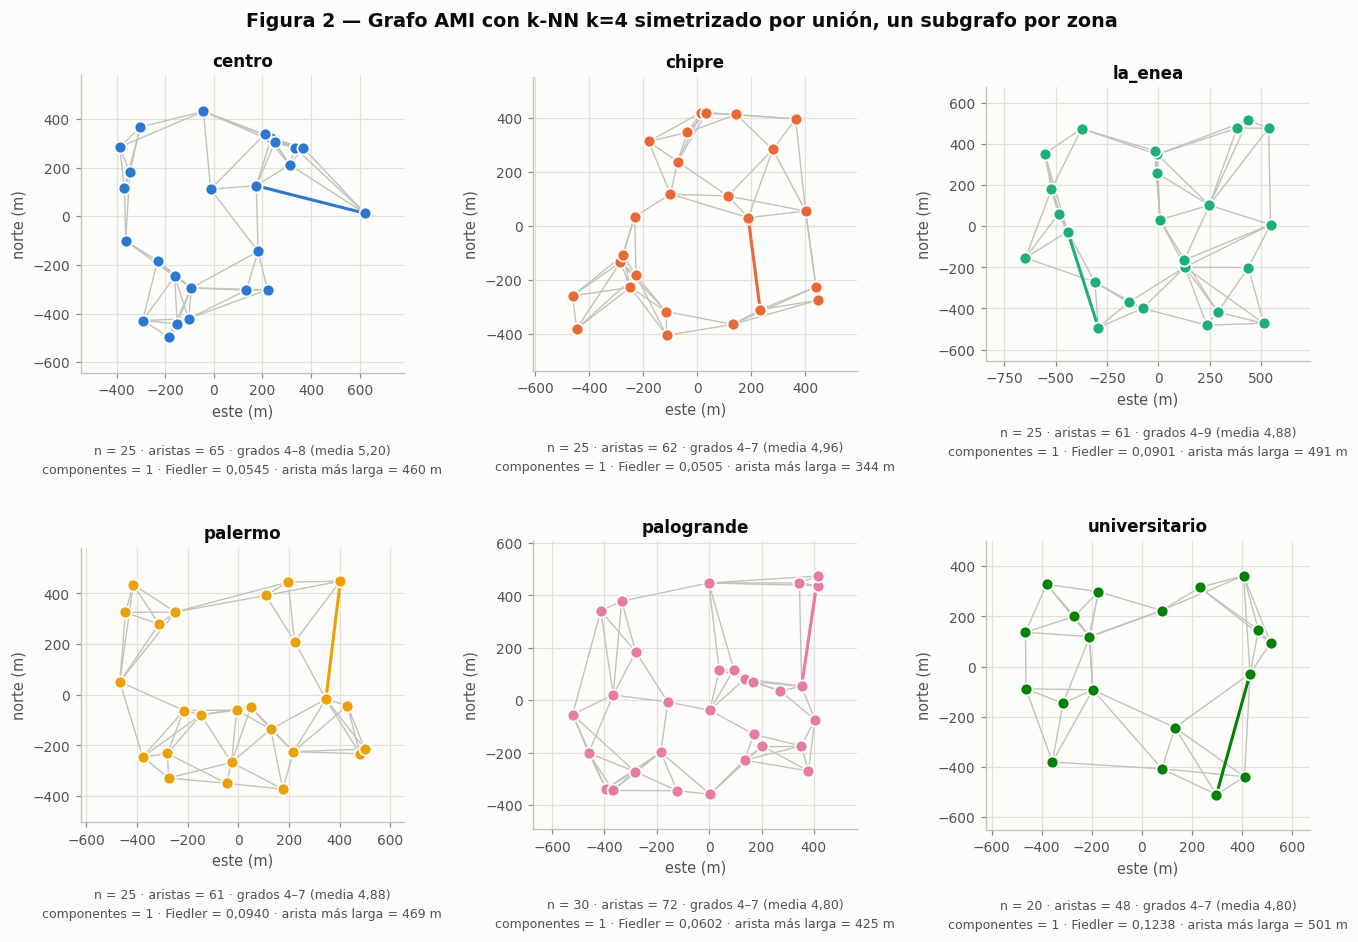

grado mínimo sobre las seis zonas: 4  (= k)
grado máximo sobre las seis zonas: 9
componentes por zona: [1]


In [6]:
# ── Figura 2: el grafo k=4, aristas visibles ─────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(12.5, 8.4))

for ax, z in zip(axes.flat, ZONAS):
    zona = grafo.zones[z]
    xy = zona.coords_m - zona.coords_m.mean(axis=0)
    A = zona.adjacency
    n = zona.n_meters

    # Aristas: hairline recesiva. La más larga, resaltada.
    i_max = j_max = 0
    d_max = -1.0
    for i in range(n):
        for j in range(i + 1, n):
            if A[i, j] > 0:
                ax.plot(xy[[i, j], 0], xy[[i, j], 1], color=AXIS, linewidth=0.9,
                        zorder=1, solid_capstyle="round")
                if zona.distances_m[i, j] > d_max:
                    d_max, i_max, j_max = zona.distances_m[i, j], i, j
    ax.plot(xy[[i_max, j_max], 0], xy[[i_max, j_max], 1], color=ZONE_COLOR[z],
            linewidth=2.0, zorder=2, solid_capstyle="round")

    ax.scatter(xy[:, 0], xy[:, 1], s=62, color=ZONE_COLOR[z], edgecolor=SURFACE,
               linewidth=1.2, zorder=3)
    ax.set_aspect("equal")
    ax.set_title(z, color=INK)
    ax.set_xlabel("este (m)")
    ax.set_ylabel("norte (m)")
    ax.margins(0.16)
    s = zona.stats
    pie_de_panel(
        ax,
        f"n = {s.n_meters} · aristas = {s.n_edges} · "
        f"grados {s.degree_min:.0f}–{s.degree_max:.0f} (media {num(s.degree_mean)})\n"
        f"componentes = {s.n_components} · Fiedler = {num(s.lambda_1, 4)} · "
        f"arista más larga = {s.max_edge_length_m:.0f} m",
        dy=-0.24,
    )

fig.suptitle("Figura 2 — Grafo AMI con k-NN k=4 simetrizado por unión, un subgrafo por zona",
             fontsize=12.5, weight="bold", y=1.0)
fig.tight_layout(h_pad=4.5)
guardar(fig, "fig2_grafo_k4")
plt.show()

print(f"grado mínimo sobre las seis zonas: "
      f"{min(z.stats.degree_min for z in grafo.zones.values()):.0f}  (= k)")
print(f"grado máximo sobre las seis zonas: "
      f"{max(z.stats.degree_max for z in grafo.zones.values()):.0f}")
print(f"componentes por zona: "
      f"{sorted({z.stats.n_components for z in grafo.zones.values()})}")

### Figura 2 — qué se concluye

**Las seis zonas quedan conexas**, que es la condición para que el espectro
signifique algo: con dos componentes el autovalor cero tendría multiplicidad 2,
el modo de Fiedler dejaría de medir cuán lejos está el grafo de partirse, y una
anomalía confinada a una componente no aparecería en el espectro de la otra.

**El grado mínimo es exactamente 4 en las seis zonas**, que es el efecto buscado
de la simetrización por unión: garantiza grado ≥ k. Eso elimina los nodos hoja
—grado 1— que el notebook E6 identificó como punto ciego del detector, porque un
nodo con un solo vecino no tiene vecindario contra el cual discrepar. El grado
máximo llega a 9, en la_enea.

**Las aristas más largas están entre 344 m (chipre) y 501 m (universitario).**
Son las que k-NN acepta para no dejar aislado a un medidor periférico, y son la
contrapartida del criterio adaptativo: en una zona rala, el cuarto vecino queda
lejos.

---

## Sección 3 — Por qué k = 4, y por qué k-NN y no radio fijo

### Figura 3 — qué muestra

Cuatro paneles que juntos justifican el criterio de vecindad por defecto.

**Panel A — barrido de k.** Una fila por zona, una columna por valor de k. El
color de la celda es el valor de Fiedler de `L_norm` cuando la zona queda conexa
—más oscuro, mejor conectada—. Las celdas grises son las zonas que quedan
fragmentadas, con el número de componentes escrito encima.

**Panel B — barrido de radio fijo.** El mismo esquema, con el radio de vecindad
en lugar de k. Aparece un tercer estado: `d=0`, zonas con algún medidor de grado
cero, para las cuales `L_norm` no está definido y el constructor levanta
`ZeroDegreeNodeError` en vez de devolver un espectro con NaN.

**Panel C — densidad por zona**, medidores por km² del *bounding box* zonal.

**Panel D — dispersión de grados**, k-NN k=4 contra radio 399 m. Cada barra es
el rango de grados observado en una zona bajo cada criterio.

figura guardada: notebooks/figures/02_fig3_knn_vs_radio.png


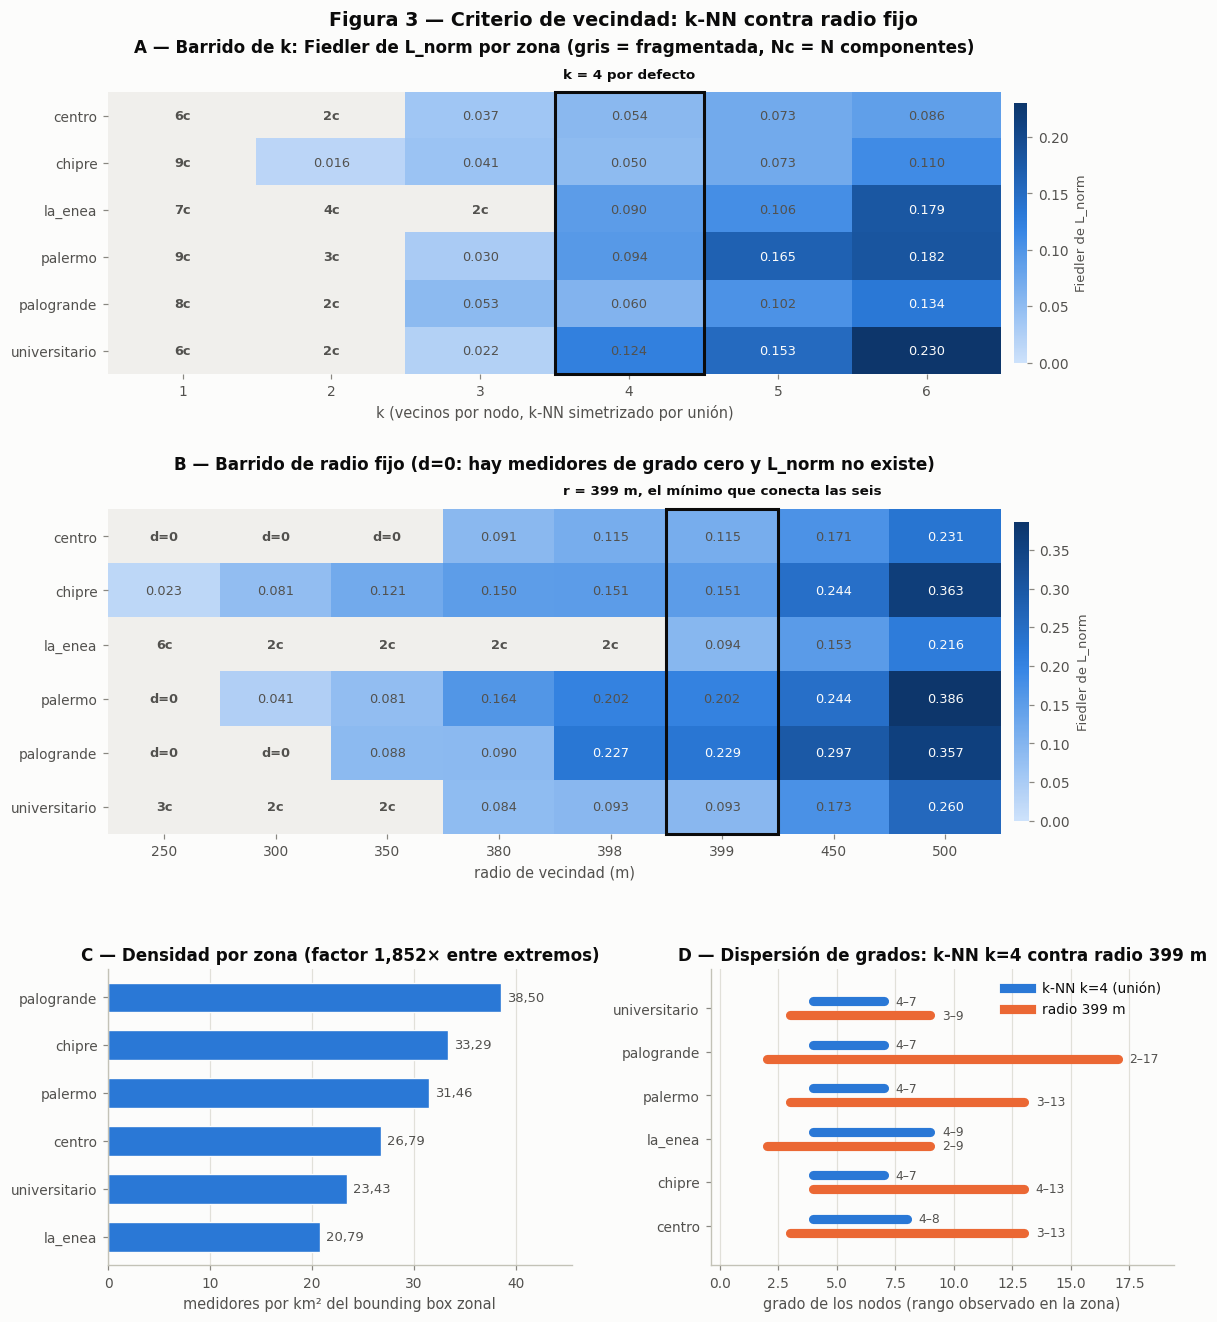

In [7]:
# ── Figura 3: k-NN contra radio ──────────────────────────────────────────────
K_GRID = [1, 2, 3, 4, 5, 6]
R_GRID = [250.0, 300.0, 350.0, 380.0, 398.0, 399.0, 450.0, 500.0]


def diagnostico(z: str, cfg: GraphConfig):
    """(fiedler, componentes, aislados) de una zona bajo una configuración."""
    de_zona = [m for m in meters if m.zona == z]
    try:
        g = build_zone_graph(de_zona, cfg)
    except ZeroDegreeNodeError:
        return None, None, True
    return g.stats.lambda_1, g.stats.n_components, False


def matriz(grid, hacer_config):
    """Rellena (fiedler, etiqueta) para cada zona y cada punto de la grilla."""
    val = np.full((len(ZONAS), len(grid)), np.nan)
    txt = [["" for _ in grid] for _ in ZONAS]
    for i, z in enumerate(ZONAS):
        for j, p in enumerate(grid):
            f, comp, aislado = diagnostico(z, hacer_config(p))
            if aislado:
                txt[i][j] = "d=0"
            elif comp > 1:
                txt[i][j] = f"{comp}c"
            else:
                val[i, j] = f
                txt[i][j] = f"{f:.3f}"
    return val, txt


val_k, txt_k = matriz(K_GRID, lambda k: GraphConfig(k=int(k)))
val_r, txt_r = matriz(R_GRID, lambda r: GraphConfig(strategy="radius", radius_m=float(r)))


def dibujar_matriz(ax, val, txt, grid, titulo, xlabel):
    """Matriz zona × parámetro, con el Fiedler en una rampa de un solo tono.

    Cada panel se normaliza a su propio máximo: los dos criterios recorren
    rangos de Fiedler distintos, y una escala común dejaría uno de los dos
    lavado contra el fondo.
    """
    vmax_p = float(np.nanmax(val))
    im = ax.imshow(np.ma.masked_invalid(val), cmap=SEQ, vmin=0.0, vmax=vmax_p,
                   aspect="auto")
    ax.set_xticks(range(len(grid)))
    ax.set_xticklabels([f"{g:g}" for g in grid])
    ax.set_yticks(range(len(ZONAS)))
    ax.set_yticklabels(ZONAS)
    ax.set_xlabel(xlabel)
    ax.set_title(titulo, color=INK, pad=26)
    ax.grid(False)
    for i in range(len(ZONAS)):
        for j in range(len(grid)):
            conexa = not np.isnan(val[i, j])
            claro = conexa and val[i, j] / vmax_p > 0.55
            ax.text(j, i, txt[i][j], ha="center", va="center", fontsize=8.4,
                    color=SURFACE if claro else INK_2,
                    weight="bold" if not conexa else "normal")
    for borde in ax.spines.values():
        borde.set_visible(False)
    cb = ax.figure.colorbar(im, ax=ax, pad=0.012, shrink=0.92)
    cb.set_label("Fiedler de L_norm", fontsize=8.6, color=INK_2)
    cb.outline.set_visible(False)
    return vmax_p


fig = plt.figure(figsize=(12.5, 13.5))
gs = fig.add_gridspec(3, 2, height_ratios=[1.0, 1.15, 1.05], hspace=0.45, wspace=0.3,
                      top=0.90)

ax_k = fig.add_subplot(gs[0, :])
dibujar_matriz(ax_k, val_k, txt_k, K_GRID,
               "A — Barrido de k: Fiedler de L_norm por zona (gris = fragmentada, Nc = N componentes)",
               "k (vecinos por nodo, k-NN simetrizado por unión)")
ax_k.add_patch(plt.Rectangle((2.5, -0.5), 1, len(ZONAS), fill=False,
                             edgecolor=INK, linewidth=2.0, zorder=5, clip_on=False))
ax_k.text(3, -0.72, "k = 4 por defecto", ha="center", va="bottom",
          fontsize=8.8, color=INK, weight="bold")

ax_r = fig.add_subplot(gs[1, :])
dibujar_matriz(ax_r, val_r, txt_r, R_GRID,
               "B — Barrido de radio fijo (d=0: hay medidores de grado cero y L_norm no existe)",
               "radio de vecindad (m)")
ax_r.add_patch(plt.Rectangle((4.5, -0.5), 1, len(ZONAS), fill=False,
                             edgecolor=INK, linewidth=2.0, zorder=5, clip_on=False))
ax_r.text(5, -0.72, "r = 399 m, el mínimo que conecta las seis", ha="center",
          va="bottom", fontsize=8.8, color=INK, weight="bold")

# Panel C — densidad
ax_d = fig.add_subplot(gs[2, 0])
orden = sorted(ZONAS, key=lambda z: densidad_zona[z])
ax_d.barh(range(len(orden)), [densidad_zona[z] for z in orden], height=0.62,
          color=ANTES, edgecolor=SURFACE, linewidth=0.9)
ax_d.set_yticks(range(len(orden)))
ax_d.set_yticklabels(orden)
ax_d.set_xlabel("medidores por km² del bounding box zonal")
factor = max(densidad_zona.values()) / min(densidad_zona.values())
ax_d.set_title(f"C — Densidad por zona (factor {num(factor, 3)}× entre extremos)", color=INK)
ax_d.grid(axis="y", visible=False)
for i, z in enumerate(orden):
    ax_d.text(densidad_zona[z] + 0.6, i, num(densidad_zona[z]), va="center",
              fontsize=8.6, color=INK_2)
ax_d.margins(x=0.18)

# Panel D — dispersión de grados, k=4 contra r=399
ax_g = fig.add_subplot(gs[2, 1])
g399 = build_ami_graph(meters, GraphConfig(strategy="radius", radius_m=399.0))
y = np.arange(len(ZONAS))
for i, z in enumerate(ZONAS):
    a, b = grafo.zones[z].stats.degree_min, grafo.zones[z].stats.degree_max
    c, d = g399.zones[z].stats.degree_min, g399.zones[z].stats.degree_max
    ax_g.plot([a, b], [i + 0.16] * 2, color=ANTES, linewidth=6.0,
              solid_capstyle="round", zorder=3)
    ax_g.plot([c, d], [i - 0.16] * 2, color=DESPUES, linewidth=6.0,
              solid_capstyle="round", zorder=3)
    ax_g.text(b + 0.5, i + 0.16, f"{a:.0f}–{b:.0f}", va="center", fontsize=8,
              color=INK_2)
    ax_g.text(d + 0.5, i - 0.16, f"{c:.0f}–{d:.0f}", va="center", fontsize=8,
              color=INK_2)
ax_g.set_yticks(y)
ax_g.set_yticklabels(ZONAS)
ax_g.set_xlabel("grado de los nodos (rango observado en la zona)")
ax_g.set_title("D — Dispersión de grados: k-NN k=4 contra radio 399 m", color=INK)
ax_g.grid(axis="y", visible=False)
ax_g.margins(x=0.16, y=0.14)
ax_g.plot([], [], color=ANTES, linewidth=6.0, label="k-NN k=4 (unión)")
ax_g.plot([], [], color=DESPUES, linewidth=6.0, label="radio 399 m")
ax_g.legend(loc="upper right")

fig.suptitle("Figura 3 — Criterio de vecindad: k-NN contra radio fijo",
             fontsize=12.5, weight="bold", y=0.955)
guardar(fig, "fig3_knn_vs_radio")
plt.show()

In [8]:
# Las tres cifras que fijan el default, impresas para que no haya que leerlas
# del color de una celda.
print("k mínimo que deja las seis zonas conexas:")
for k in K_GRID:
    estados = [diagnostico(z, GraphConfig(k=k)) for z in ZONAS]
    conexas = sum(1 for f, c, a in estados if not a and c == 1)
    peor = min(((f, z) for (f, c, a), z in zip(estados, ZONAS) if not a and c == 1),
               default=(None, None))
    fragmentadas = [z for (f, c, a), z in zip(estados, ZONAS) if a or c > 1]
    extra = f"  min Fiedler {peor[0]:.4f} ({peor[1]})" if peor[0] else ""
    print(f"  k={k}  conexas {conexas}/6{extra}"
          + (f"  fragmentadas: {fragmentadas}" if fragmentadas else ""))

print("\nradio mínimo que deja las seis zonas conexas:")
for r in (398.0, 399.0):
    estados = [diagnostico(z, GraphConfig(strategy="radius", radius_m=r)) for z in ZONAS]
    partidas = {z: c for (f, c, a), z in zip(estados, ZONAS) if not a and c > 1}
    print(f"  r={r:.0f} m  partidas: {partidas or 'ninguna'}")

print("\ngrados a r=399 m, por zona:")
for z in ZONAS:
    s = g399.zones[z].stats
    print(f"  {z:<14} {s.degree_min:.0f} a {s.degree_max:.0f}   (k=4: "
          f"{grafo.zones[z].stats.degree_min:.0f} a {grafo.zones[z].stats.degree_max:.0f})")

print("\nknn_mode='mutual' con k=4:")
for z in ZONAS:
    f, c, a = diagnostico(z, GraphConfig(k=4, knn_mode="mutual"))
    print(f"  {z:<14} " + ("medidores de grado cero" if a
                           else f"conexa, Fiedler {f:.4f}" if c == 1
                           else f"{c} componentes"))

k mínimo que deja las seis zonas conexas:
  k=1  conexas 0/6  fragmentadas: ['centro', 'chipre', 'la_enea', 'palermo', 'palogrande', 'universitario']
  k=2  conexas 1/6  min Fiedler 0.0155 (chipre)  fragmentadas: ['centro', 'la_enea', 'palermo', 'palogrande', 'universitario']
  k=3  conexas 5/6  min Fiedler 0.0219 (universitario)  fragmentadas: ['la_enea']
  k=4  conexas 6/6  min Fiedler 0.0505 (chipre)
  k=5  conexas 6/6  min Fiedler 0.0725 (centro)
  k=6  conexas 6/6  min Fiedler 0.0862 (centro)

radio mínimo que deja las seis zonas conexas:
  r=398 m  partidas: {'la_enea': 2}
  r=399 m  partidas: ninguna

grados a r=399 m, por zona:
  centro         3 a 13   (k=4: 4 a 8)
  chipre         4 a 13   (k=4: 4 a 7)
  la_enea        2 a 9   (k=4: 4 a 9)
  palermo        3 a 13   (k=4: 4 a 7)
  palogrande     2 a 17   (k=4: 4 a 7)
  universitario  3 a 9   (k=4: 4 a 7)

knn_mode='mutual' con k=4:
  centro         medidores de grado cero
  chipre         2 componentes
  la_enea        2 compo

### Figura 3 — qué se concluye

**k = 4 es el mínimo que deja las seis zonas conexas.** No es holgura sobre el
mínimo: es el mínimo. El panel A lo muestra en una sola columna — con k = 3
cinco zonas conectan sin problema, la peor de ellas universitario con Fiedler
0,0219, y **la_enea se parte en dos componentes**.

**El límite lo fija una sola zona, y dos criterios independientes coinciden en
cuál.** Por k-NN, k = 3 parte la_enea y sólo la_enea. Por radio fijo, r = 399 m
es el radio mínimo que conecta las seis, y un metro menos —r = 398 m— parte
la_enea y sólo la_enea. Que la zona crítica sea la misma bajo dos criterios de
vecindad distintos dice que el límite no es un artefacto del criterio elegido
sino una propiedad de la distribución espacial: la_enea es la más rala (panel C,
20,79 med/km²) y fija el punto de operación de toda la construcción.

**El radio fijo no sirve, y el panel D dice por qué.** A r = 399 m las seis
zonas quedan conexas, así que la conectividad no distingue entre los dos
criterios; lo que los distingue es la dispersión de grados. Con radio los grados
van de **2 a 17**; con k-NN k = 4, de **4 a 9**, con el mínimo garantizado en k
por la simetrización por unión. Un único radio no puede servir a la vez a una
zona de 20,79 med/km² y a otra de 38,50: donde alcanza para conectar la rala, es
excesivo para la densa. Por debajo de 350 m el radio además produce medidores de
grado cero, para los cuales `L_norm` no está definido.

**La reciprocidad fragmenta.** `knn_mode="mutual"` con k = 4 deja conexa sólo a
palogrande, con Fiedler 0,0270 —la mitad del peor caso con unión—, parte chipre
y la_enea en 2 componentes, palermo y universitario en 3, y en centro deja un
medidor de grado cero. Por eso el defecto es la unión.

---

## Sección 4 — El espectro por zona

### Figura 4 — qué muestra

Los autovalores de `L_norm` de cada zona, en orden ascendente. Un panel por
zona, cada punto un modo del grafo.

Lo que hay que mirar son las **franjas grises**: marcan los subespacios propios
degenerados, los grupos de autovalores repetidos que devuelve
`spectral.degenerate_groups`. Dentro de uno de esos grupos la base de
autovectores que devuelve `eigh` es **arbitraria** —permutar el orden de los
nodos la cambia—, así que ningún resultado del monitor puede depender de un
autovector individual de esa región. Los grupos en λ = 1,25 van rotulados con su
multiplicidad.

La línea vertical marca el corte de bandas que elige `band_cut_index`, que por
construcción cae siempre en un **borde** de subespacio y nunca dentro de uno.

figura guardada: notebooks/figures/02_fig4_espectro.png


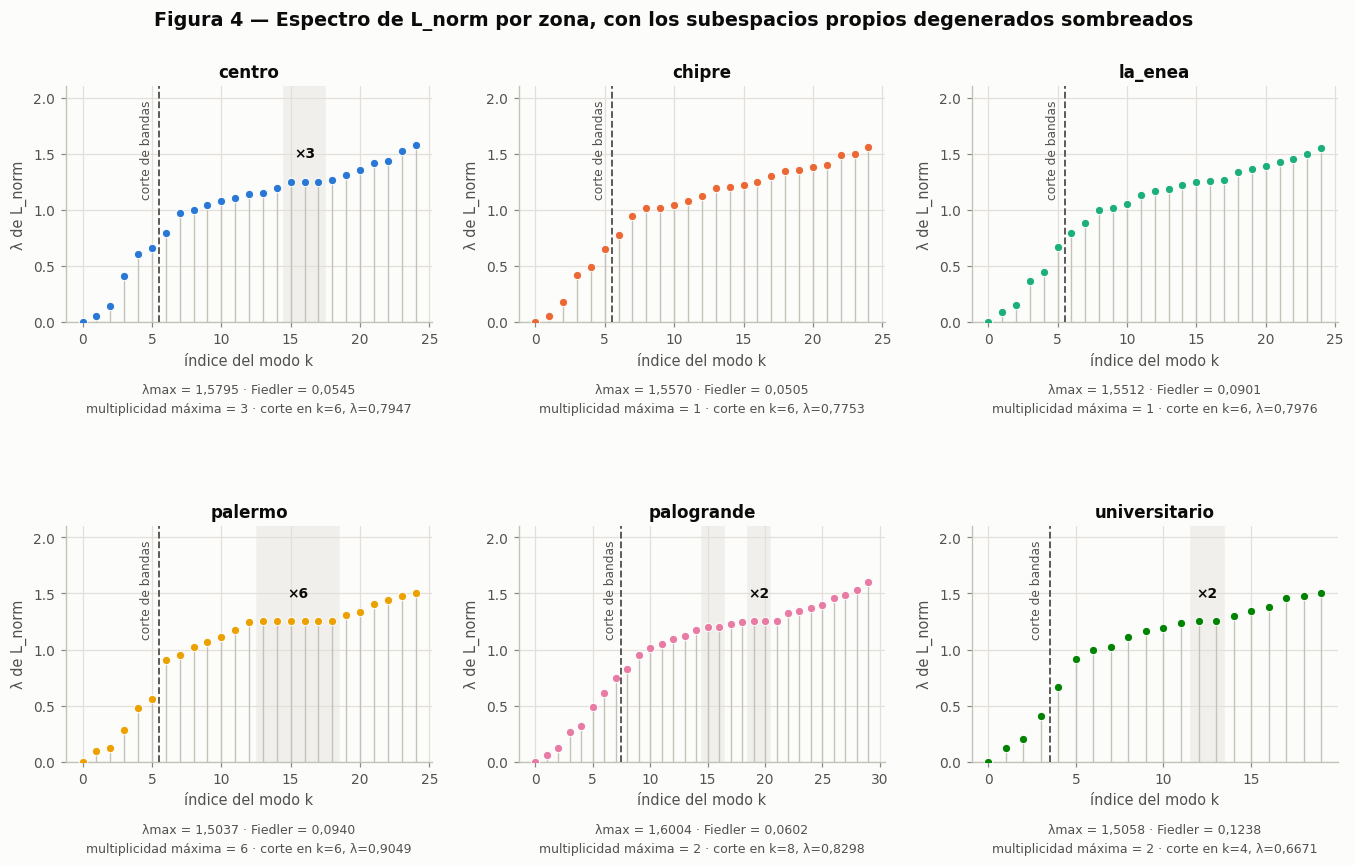

In [9]:
# ── Figura 4: el espectro por zona ───────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(12.5, 8.0))

for ax, z in zip(axes.flat, ZONAS):
    zona = grafo.zones[z]
    lam = zona.eigenvalues
    k = np.arange(lam.size)
    grupos = degenerate_groups(lam)
    corte = band_cut_index(lam)

    # Subespacios degenerados: franja gris detrás de los modos que agrupan.
    for g in grupos:
        if len(g) > 1:
            ax.axvspan(g[0] - 0.45, g[-1] + 0.45, color=NEUTRAL, zorder=0)
            if abs(lam[g[0]] - 1.25) < 1e-9:
                ax.annotate(
                    f"×{len(g)}", xy=((g[0] + g[-1]) / 2, lam[g[0]]),
                    xytext=(0, 16), textcoords="offset points", ha="center",
                    fontsize=9, weight="bold", color=INK,
                )

    ax.vlines(k, 0, lam, color=AXIS, linewidth=0.9, zorder=2)
    ax.scatter(k, lam, s=30, color=ZONE_COLOR[z], edgecolor=SURFACE,
               linewidth=0.7, zorder=3)
    ax.axvline(corte - 0.5, color=INK_2, linestyle="--", linewidth=1.2, zorder=4)
    ax.text(corte - 0.9, 1.98, "corte de bandas", fontsize=8, color=INK_2,
            va="top", ha="right", rotation=90)

    ax.set_ylim(0, 2.1)
    ax.set_title(z, color=INK)
    ax.set_xlabel("índice del modo k")
    ax.set_ylabel("λ de L_norm")
    mult = max(len(g) for g in grupos)
    pie_de_panel(
        ax,
        f"λmax = {num(lam[-1], 4)} · Fiedler = {num(zona.stats.lambda_1, 4)}\n"
        f"multiplicidad máxima = {mult} · corte en k={corte}, λ={num(lam[corte], 4)}",
        dy=-0.26,
    )

fig.suptitle("Figura 4 — Espectro de L_norm por zona, con los subespacios propios degenerados "
             "sombreados", fontsize=12.5, weight="bold", y=1.0)
fig.tight_layout(h_pad=4.5)
guardar(fig, "fig4_espectro")
plt.show()

In [10]:
# Multiplicidades y cortes, en números.
filas = []
for z in ZONAS:
    lam = grafo.zones[z].eigenvalues
    grupos = degenerate_groups(lam)
    en_125 = [len(g) for g in grupos if abs(lam[g[0]] - 1.25) < 1e-9]
    corte = band_cut_index(lam)
    bordes = {g[0] for g in grupos}
    filas.append({
        "zona": z,
        "lambda max": round(float(lam[-1]), 4),
        "multiplicidad máxima": max(len(g) for g in grupos),
        "mult. en lambda=1,25": en_125[0] if en_125 else 0,
        "objetivo del corte": round(0.5 * float(lam[-1]), 4),
        "corte (índice)": corte,
        "corte (lambda)": round(float(lam[corte]), 4),
        "es borde de subespacio": corte in bordes,
    })
espectros = pd.DataFrame(filas).set_index("zona")

nulos = sum(int((np.abs(grafo.zones[z].eigenvalues) < 1e-8).sum()) for z in ZONAS)
print(f"autovalores nulos sumando las seis zonas: {nulos}  (= {grafo.n_zones} zonas)")
print("el grafo global es bloque-diagonal: un cero por componente conexa\n")
espectros

autovalores nulos sumando las seis zonas: 6  (= 6 zonas)
el grafo global es bloque-diagonal: un cero por componente conexa



,lambda max,multiplicidad máxima,"mult. en lambda=1,25",objetivo del corte,corte (índice),corte (lambda),es borde de subespacio
zona,,,,,,,
centro,1.5795,3,3,0.7897,6,0.7947,True
chipre,1.5570,1,1,0.7785,6,0.7753,True
la_enea,1.5512,1,1,0.7756,6,0.7976,True
palermo,1.5037,6,6,0.7519,6,0.9049,True
palogrande,1.6004,2,2,0.8002,8,0.8298,True
universitario,1.5058,2,2,0.7529,4,0.6671,True


### Figura 4 — qué se concluye

**El espectro vive en `[0, 2]`**, como debe para un Laplaciano normalizado, y
λmax va de 1,5037 (palermo) a 1,6004 (palogrande). Ninguna zona se acerca a 2,
que es el valor que alcanzaría un grafo bipartito.

**La degeneración espectral no es hipotética en este grafo.** λ = 1,25 aparece
con multiplicidad **6 en palermo**, 3 en centro y 2 en palogrande y
universitario. El valor no es casual: son grupos de nodos gemelos de grado 4, y
`1 + 1/4` es exactamente el autovalor que produce un par de nodos con la misma
vecindad. Dentro de esos subespacios los autovectores individuales no son
reproducibles, y ésa es la razón por la que el monitor reporta **energía de
Dirichlet** —una forma cuadrática del operador, independiente de la base— en vez
de coeficientes espectrales sueltos. La Sección 5 lo mide.

**El corte de bandas cae siempre en un borde de subespacio.** La última columna
de la tabla lo confirma en las seis zonas. El ajuste hace trabajo real: en
palermo mueve el corte de su objetivo 0,752 a 0,905 para no partir el subespacio
de dimensión 6. Un corte fijo en λmax/2 podría caer justo sobre un autovalor
repetido, y entonces el error de redondeo decidiría qué miembros del subespacio
van a cada banda.

**El autovalor cero tiene multiplicidad 6 en el grafo global**, una por zona.
Es la firma de la estructura bloque-diagonal: el análisis por zona no es una
aproximación del análisis global, es exactamente el análisis global reordenado.

---

## Sección 5 — El Difuminador

### Figura 5 — qué muestra

El efecto del filtro paso-bajo sobre la zona **la_enea**, con τ = 0,5, el valor
por defecto. La señal es la del experimento: consumo base de 10 kWh, ruido
gaussiano de desviación 0,3 y un pico de +5 kWh en un único medidor sorteado con
semilla fija.

**Paneles A y B — el grafo antes y después**, con el color de cada nodo
proporcional a su lectura, en la misma escala. Es la vista que muestra qué hace
el filtro espacialmente.

**Panel C — la señal medidor por medidor**, antes y después. Se ve a la vez el
pico atenuado y el nivel de base preservado.

**Panel D — el espectro `|x̂|`** de las dos señales, con el corte de bandas
marcado. Es donde se ve que el filtro no borra la señal: borra la parte del
espectro que está por encima del corte.

La métrica principal es la **energía de Dirichlet**
`E_D(x) = xᵀ·L_norm·x = Σ_ij w_ij·(xᵢ/√dᵢ − xⱼ/√dⱼ)²`, que mide el desacuerdo
entre vecinos y no depende de la base de autovectores.

figura guardada: notebooks/figures/02_fig5_difuminador.png


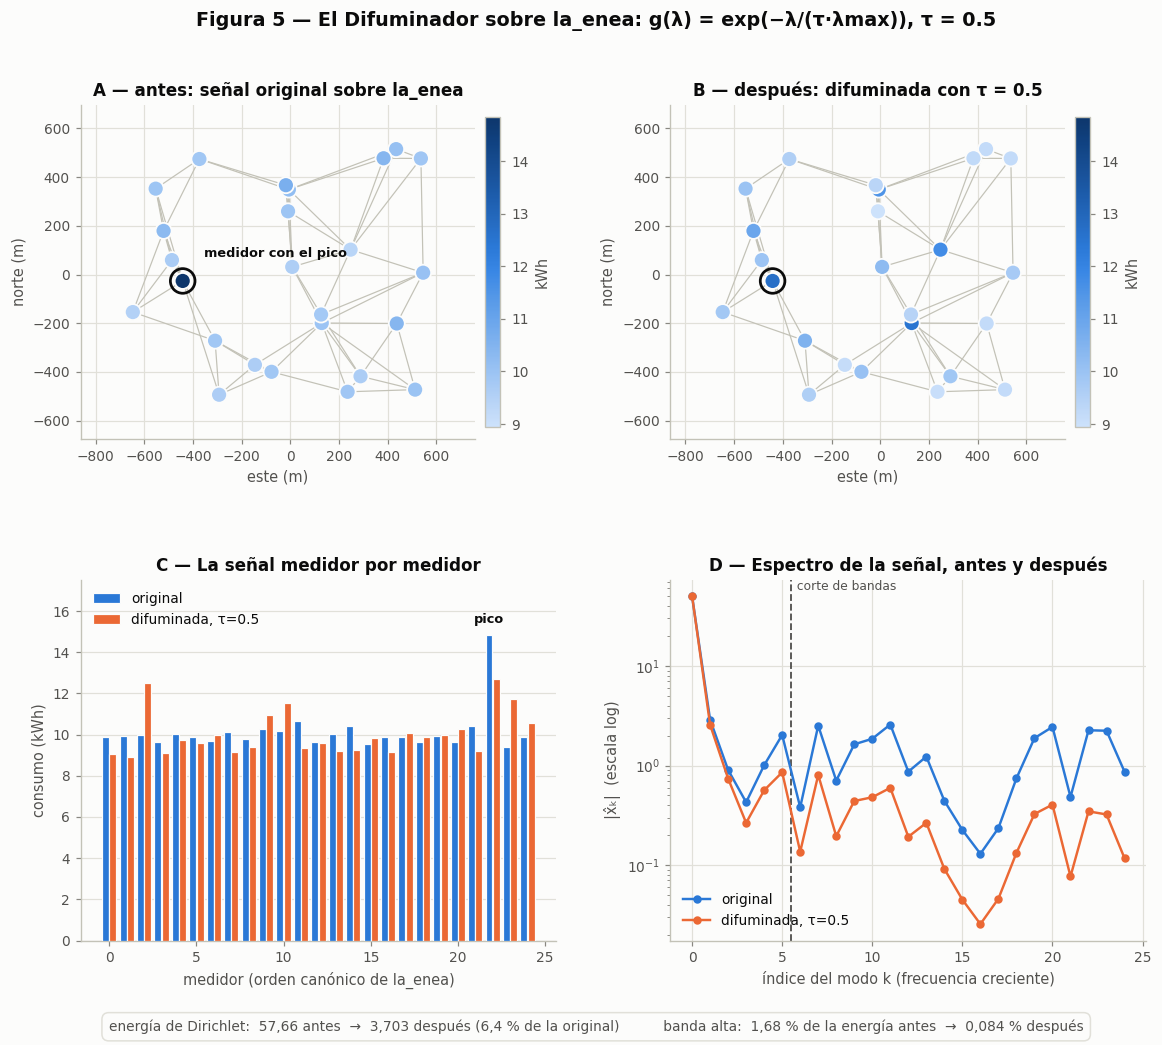

In [11]:
# ── Figura 5: el Difuminador sobre la_enea ───────────────────────────────────
Z_DEMO = "la_enea"
zona = grafo.zones[Z_DEMO]
x = signals[Z_DEMO].values
x_f = diffuse(zona, x, DEFAULT_TAU)

ed_antes, ed_despues = dirichlet_energy(zona, x), dirichlet_energy(zona, x_f)
banda_antes, banda_despues = band_energy(zona, x), band_energy(zona, x_f)
xy = zona.coords_m - zona.coords_m.mean(axis=0)
i_pico = signals[Z_DEMO].spike_index

fig = plt.figure(figsize=(12.5, 10.0))
gs = fig.add_gridspec(2, 2, height_ratios=[1.05, 1.0], hspace=0.32, wspace=0.24,
                      top=0.90, bottom=0.12)

vmin, vmax_s = float(min(x.min(), x_f.min())), float(max(x.max(), x_f.max()))
for col, (datos, titulo) in enumerate([
    (x, f"A — antes: señal original sobre {Z_DEMO}"),
    (x_f, f"B — después: difuminada con τ = {DEFAULT_TAU}"),
]):
    ax = fig.add_subplot(gs[0, col])
    for i in range(zona.n_meters):
        for j in range(i + 1, zona.n_meters):
            if zona.adjacency[i, j] > 0:
                ax.plot(xy[[i, j], 0], xy[[i, j], 1], color=AXIS, linewidth=0.8,
                        zorder=1)
    sc = ax.scatter(xy[:, 0], xy[:, 1], c=datos, cmap=SEQ, vmin=vmin, vmax=vmax_s,
                    s=110, edgecolor=SURFACE, linewidth=1.2, zorder=3)
    ax.scatter(xy[i_pico, 0], xy[i_pico, 1], s=260, facecolor="none",
               edgecolor=INK, linewidth=1.8, zorder=4)
    if col == 0:
        ax.annotate("medidor con el pico", xy=(xy[i_pico, 0], xy[i_pico, 1]),
                    xytext=(14, 16), textcoords="offset points", fontsize=8.4,
                    color=INK, weight="bold")
    ax.set_aspect("equal")
    ax.set_title(titulo, color=INK)
    ax.set_xlabel("este (m)")
    ax.set_ylabel("norte (m)")
    ax.margins(0.18)
    fig.colorbar(sc, ax=ax, shrink=0.82, pad=0.02).set_label("kWh", color=INK_2)

# Panel C — la señal nodo por nodo
ax = fig.add_subplot(gs[1, 0])
pos = np.arange(zona.n_meters)
ax.bar(pos - 0.21, x, width=0.4, color=ANTES, edgecolor=SURFACE, linewidth=0.8,
       label="original", zorder=3)
ax.bar(pos + 0.21, x_f, width=0.4, color=DESPUES, edgecolor=SURFACE,
       linewidth=0.8, label=f"difuminada, τ={DEFAULT_TAU}", zorder=3)
ax.set_xlabel(f"medidor (orden canónico de {Z_DEMO})")
ax.set_ylabel("consumo (kWh)")
ax.set_title("C — La señal medidor por medidor", color=INK)
ax.set_ylim(0, max(x.max(), x_f.max()) * 1.18)
ax.grid(axis="x", visible=False)
ax.legend(loc="upper left", ncols=1)
ax.annotate("pico", xy=(i_pico - 0.21, x[i_pico]), xytext=(0, 8),
            textcoords="offset points", ha="center", fontsize=8.4, color=INK,
            weight="bold")

# Panel D — el espectro
ax = fig.add_subplot(gs[1, 1])
x_hat, x_f_hat = gft(x, zona.eigenvectors), gft(x_f, zona.eigenvectors)
corte = banda_antes.cut_index
ax.semilogy(pos, np.abs(x_hat), marker="o", markersize=4.5, linewidth=1.6,
            color=ANTES, label="original", zorder=3)
ax.semilogy(pos, np.abs(x_f_hat), marker="o", markersize=4.5, linewidth=1.6,
            color=DESPUES, label=f"difuminada, τ={DEFAULT_TAU}", zorder=3)
ax.axvline(corte - 0.5, color=INK_2, linestyle="--", linewidth=1.2, zorder=2)
ax.text(corte - 0.4, ax.get_ylim()[1], " corte de bandas", fontsize=8,
        color=INK_2, va="top")
ax.set_xlabel("índice del modo k (frecuencia creciente)")
ax.set_ylabel("|x̂ₖ|  (escala log)")
ax.set_title("D — Espectro de la señal, antes y después", color=INK)
ax.legend(loc="lower left")

# Las cifras van fuera de los ejes: adentro taparían la curva.
fig.text(
    0.5, 0.035,
    f"energía de Dirichlet:  {num(ed_antes)} antes  →  {num(ed_despues, 3)} después "
    f"({num(100 * ed_despues / ed_antes, 1)} % de la original)          "
    f"banda alta:  {num(100 * banda_antes.high_fraction, 2)} % de la energía antes  →  "
    f"{num(100 * banda_despues.high_fraction, 3)} % después",
    ha="center", va="bottom", fontsize=9, color=INK_2,
    bbox=dict(facecolor=SURFACE, edgecolor=GRID, boxstyle="round,pad=0.5"),
)

fig.suptitle(f"Figura 5 — El Difuminador sobre {Z_DEMO}: g(λ) = exp(−λ/(τ·λmax)), "
             f"τ = {DEFAULT_TAU}", fontsize=12.5, weight="bold", y=0.965)
guardar(fig, "fig5_difuminador")
plt.show()

In [12]:
# El efecto del filtro en las seis zonas, no sólo en la de la figura.
filas = []
for z in ZONAS:
    zz = grafo.zones[z]
    xz = signals[z].values
    xz_f = diffuse(zz, xz, DEFAULT_TAU)
    b, b_f = band_energy(zz, xz), band_energy(zz, xz_f)
    e, e_f = dirichlet_energy(zz, xz), dirichlet_energy(zz, xz_f)
    filas.append({
        "zona": z,
        "E_D original": round(e, 2),
        "E_D difuminada": round(e_f, 3),
        "E_D retenida": f"{e_f / e:.1%}",
        "banda alta original": f"{b.high_fraction:.2%}",
        "banda alta difuminada": f"{b_f.high_fraction:.3%}",
        "banda alta retenida": f"{b_f.high / b.high:.1%}",
    })
efecto = pd.DataFrame(filas).set_index("zona")

razones = [dirichlet_energy(grafo.zones[z], diffuse(grafo.zones[z], signals[z].values,
           DEFAULT_TAU)) / dirichlet_energy(grafo.zones[z], signals[z].values)
           for z in ZONAS]
print(f"E_D retenida con τ={DEFAULT_TAU}: entre {min(razones):.2%} y {max(razones):.2%} "
      f"sobre las seis zonas\n")

# Los paneles A y B muestran un efecto que conviene tener medido: al difuminar,
# la señal se acerca al núcleo de L_norm, que es D^(1/2)·1 y no la constante.
print("coseno de la señal contra √d (el núcleo de L_norm), antes y después:")
for z in ZONAS:
    zz = grafo.zones[z]
    nucleo = np.sqrt(zz.degrees)
    cos = lambda v: float(v @ nucleo / (np.linalg.norm(v) * np.linalg.norm(nucleo)))
    print(f"  {z:<14} {cos(signals[z].values):.4f}  →  "
          f"{cos(diffuse(zz, signals[z].values, DEFAULT_TAU)):.4f}")
print()
efecto

E_D retenida con τ=0.5: entre 4.94% y 7.01% sobre las seis zonas

coseno de la señal contra √d (el núcleo de L_norm), antes y después:
  centro         0.9916  →  0.9988
  chipre         0.9926  →  0.9990
  la_enea        0.9888  →  0.9980
  palermo        0.9912  →  0.9993
  palogrande     0.9911  →  0.9989
  universitario  0.9955  →  0.9993



,E_D original,E_D difuminada,E_D retenida,banda alta original,banda alta difuminada,banda alta retenida
zona,,,,,,
centro,45.02,3.156,7.0%,1.30%,0.071%,5.4%
chipre,42.79,2.357,5.5%,1.18%,0.051%,4.2%
la_enea,57.66,3.703,6.4%,1.68%,0.084%,4.9%
palermo,51.67,2.553,4.9%,1.59%,0.071%,4.4%
palogrande,62.33,3.584,5.8%,1.45%,0.058%,3.9%
universitario,19.72,1.240,6.3%,0.65%,0.025%,3.8%


### Figura 5 — qué se concluye

**El filtro atenúa el desacuerdo entre vecinos y deja el nivel de base intacto.**
Con τ = 0,5 la energía de Dirichlet queda entre el 4,94 % y el 7,01 % de su valor
original en las seis zonas, y la energía de banda alta entre el 3,7 % y el 5,4 %
de la suya. Es el comportamiento de un paso-bajo.

**El pico no desaparece: se reparte.** Los paneles A y B lo muestran mejor que
cualquier número — el medidor anómalo baja, y sus vecinos suben. Eso es lo que
hace un filtro de difusión, y es también la razón por la que el Difuminador es un
paso previo al detector y no el detector mismo: lo que el detector va a mirar es
el **residuo** entre la señal y su versión difuminada, no la difuminada.

**Hay un segundo efecto en el panel B que conviene no leer como un error.**
Después de difuminar aparecen nodos oscuros donde antes no los había, y no están
cerca del pico: están donde el grado es alto. No es un artefacto. Con τ → 0 el
filtro converge a la proyección sobre el **núcleo de `L_norm`**, que **no** es la
señal constante sino `D^(1/2)·1` — el vector cuya componente `i` vale `√dᵢ`. Con
τ = 0,5 ya se está yendo en esa dirección, y la medición lo confirma: el coseno
de la señal contra `√d` sube de 0,9888 a 0,9980 en la_enea, y en la misma
dirección en las seis zonas. Quien espere ver un promedio y encuentre un perfil
que crece con el grado no está mirando un error: está mirando el núcleo correcto
del operador que se eligió.

**El panel D es el que desmiente la lectura ingenua.** El filtro no atenúa la
señal: atenúa las frecuencias altas. El coeficiente de frecuencia cero queda
intacto —`g(0) = 1` para cualquier τ— y por eso la banda baja retiene entre el
99,7 % y el 100 % de su energía en todo el barrido. Esa métrica **no es
informativa**: la banda baja está dominada por el coeficiente de media, que
concentra entre el 97,8 % y el 99,1 % de la energía total porque la señal tiene
media 10 kWh y desviación 0,3. Las métricas que dicen algo son la energía de
Dirichlet y la banda alta.

**Sobre el signo del exponente.** La formulación publicada en Aristizábal (2022,
Cap. 3) escribe el exponente **positivo**. Con ese signo `g` crece con λ y el
filtro amplifica la energía de Dirichlet entre 24 y 38 veces en vez de
atenuarla, además de desbordar a infinito para τ chico. UrbIA implementa el signo
negativo y no expone el otro como opción configurable; la medición completa está
en `experiments/difuminador-tau/RESULTADOS.md` §3 y la decisión en el ADR-003
§3.5.

---

## Sección 6 — El barrido de τ y el rango estable

### Figura 6 — qué muestra

Los tres paneles que delimitan el rango de τ que después debe explorar el
*Afinador*, el componente que ajusta τ por aprendizaje por refuerzo. La curva se
recalcula acá llamando a `measure_knees` del script del experimento, sobre una
grilla de 81 puntos equiespaciados en log(τ) entre 0,01 y 100.

**Panel A — energía de Dirichlet retenida**, `E_D(x_filtrada) / E_D(x)`. La línea
es el promedio de las seis zonas; la banda, el rango entre la zona que más retiene
y la que menos. Valores chicos significan filtrado agresivo.

**Panel B — dispersión entre zonas**, el cociente entre la zona que más retiene y
la que menos. Mide si una misma τ significa lo mismo en las seis zonas, que es la
condición para un monitor distribuido.

**Panel C — sensibilidad** `|d ln E_D / d ln τ|`: cuántos por ciento cambia la
energía retenida por cada por ciento de cambio en τ. Es la elasticidad de la
respuesta, y determina si un agente puede ajustar τ por realimentación.

La franja vertical es el **rango estable**, con los codos localizados por
criterios declarados antes de mirar los datos: por abajo, el τ más chico donde la
dispersión baja de 1,5; por arriba, el τ más grande donde el filtro todavía
remueve al menos la mitad de `E_D`.

figura guardada: notebooks/figures/02_fig6_barrido_tau.png


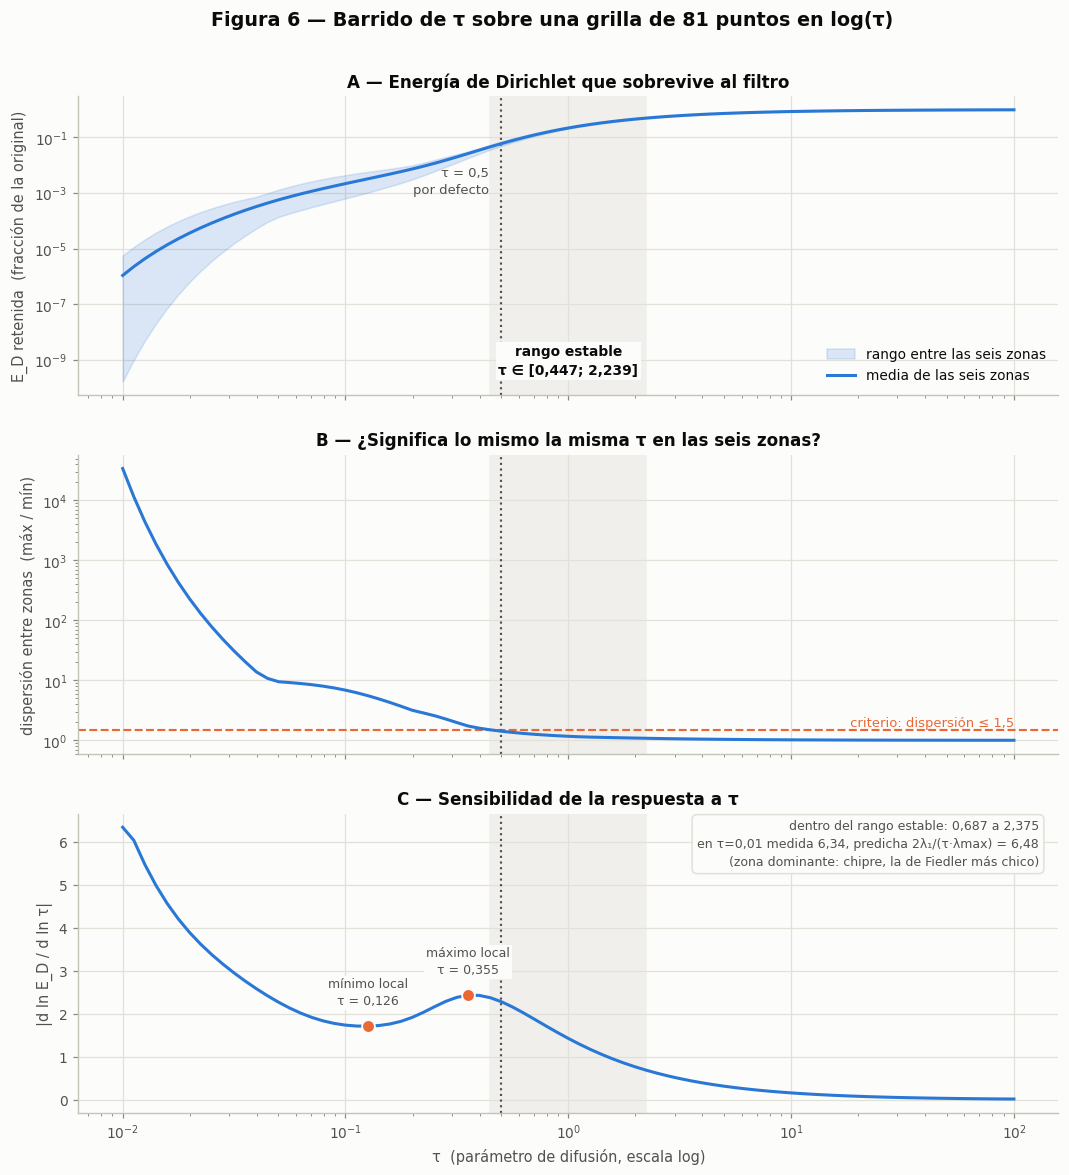

In [13]:
# ── Figura 6: barrido de τ ───────────────────────────────────────────────────
# La curva y los codos salen del script del experimento, no de código nuevo.
codos = exp.measure_knees(grafo, signals)
curva = pd.DataFrame(codos["curva"])
tau_lo, tau_hi = codos["codo_inferior_tau"], codos["codo_superior_tau"]

# Rango por zona en cada τ de la grilla, para la banda del panel A.
por_zona = np.array([
    [dirichlet_energy(grafo.zones[z], diffuse(grafo.zones[z], signals[z].values, t))
     / dirichlet_energy(grafo.zones[z], signals[z].values) for z in ZONAS]
    for t in curva["tau"]
])

dentro = curva[(curva["tau"] >= tau_lo) & (curva["tau"] <= tau_hi)]
sens_lo, sens_hi = dentro["sensibilidad_log"].min(), dentro["sensibilidad_log"].max()

fig, axes = plt.subplots(3, 1, figsize=(11.5, 12.0), sharex=True)


def franja(ax, etiqueta: bool = False) -> None:
    ax.axvspan(tau_lo, tau_hi, color=NEUTRAL, zorder=0)
    ax.axvline(DEFAULT_TAU, color=INK_2, linestyle=":", linewidth=1.4, zorder=2)
    if etiqueta:
        ax.annotate(f"rango estable\nτ ∈ [{num(tau_lo, 3)}; {num(tau_hi, 3)}]",
                    xy=(np.sqrt(tau_lo * tau_hi), 0.06),
                    xycoords=("data", "axes fraction"), ha="center", va="bottom",
                    fontsize=9, weight="bold", color=INK, linespacing=1.4,
                    bbox=dict(facecolor=SURFACE, edgecolor="none", pad=1.8))


# Panel A
ax = axes[0]
ax.fill_between(curva["tau"], por_zona.min(axis=1), por_zona.max(axis=1),
                color=ANTES, alpha=0.16, zorder=1,
                label="rango entre las seis zonas")
ax.plot(curva["tau"], curva["dirichlet_media"], color=ANTES, linewidth=2.0,
        zorder=3, label="media de las seis zonas")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_ylabel("E_D retenida  (fracción de la original)")
ax.set_title("A — Energía de Dirichlet que sobrevive al filtro", color=INK)
franja(ax, etiqueta=True)
ax.legend(loc="lower right")
ax.annotate(f"τ = {num(DEFAULT_TAU, 1)}\npor defecto", xy=(DEFAULT_TAU, 1e-3),
            xytext=(-8, 0), textcoords="offset points", ha="right", fontsize=8.6,
            color=INK_2, linespacing=1.4)

# Panel B
ax = axes[1]
ax.plot(curva["tau"], curva["dispersion"], color=ANTES, linewidth=2.0, zorder=3)
ax.axhline(1.5, color=DESPUES, linestyle="--", linewidth=1.4, zorder=2)
ax.text(curva["tau"].iloc[-1], 1.5, " criterio: dispersión ≤ 1,5", ha="right",
        va="bottom", fontsize=8.6, color=DESPUES)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_ylabel("dispersión entre zonas  (máx / mín)")
ax.set_title("B — ¿Significa lo mismo la misma τ en las seis zonas?", color=INK)
franja(ax)

# Panel C
ax = axes[2]
ax.plot(curva["tau"], curva["sensibilidad_log"], color=ANTES, linewidth=2.0,
        zorder=3)
ACENTOS = {"maximo": "máximo", "minimo": "mínimo"}
for extremo in codos["sensibilidad_extremos_interiores"]:
    ax.scatter([extremo["tau"]], [extremo["valor"]], s=70, color=DESPUES,
               edgecolor=SURFACE, linewidth=1.2, zorder=4)
    ax.annotate(f"{ACENTOS[extremo['tipo']]} local\nτ = {num(extremo['tau'], 3)}",
                xy=(extremo["tau"], extremo["valor"]), xytext=(0, 14),
                textcoords="offset points", ha="center", fontsize=8.2,
                color=INK_2, linespacing=1.4,
                bbox=dict(facecolor=SURFACE, edgecolor="none", pad=1.4))
ax.set_xscale("log")
ax.set_xlabel("τ  (parámetro de difusión, escala log)")
ax.set_ylabel("|d ln E_D / d ln τ|")
ax.set_title("C — Sensibilidad de la respuesta a τ", color=INK)
franja(ax)
anotar(ax,
       f"dentro del rango estable: {num(sens_lo, 3)} a {num(sens_hi, 3)}\n"
       f"en τ=0,01 medida {num(codos['sensibilidad_en_tau_min'])}, "
       f"predicha 2λ₁/(τ·λmax) = {num(codos['sensibilidad_teorica_en_tau_min'])}\n"
       f"(zona dominante: {codos['zona_dominante']}, la de Fiedler más chico)",
       loc="upper right")

fig.suptitle("Figura 6 — Barrido de τ sobre una grilla de "
             f"{codos['n_puntos']} puntos en log(τ)",
             fontsize=12.5, weight="bold", y=0.945)
guardar(fig, "fig6_barrido_tau")
plt.show()

In [14]:
# La grilla de reporte de RESULTADOS.md, para leer las cifras exactas.
sweep = pd.DataFrame([
    {
        "tau": f["tau"],
        "E_D retenida (media)": f"{f['dirichlet_media']:.2e}",
        "dispersión": round(f["dispersion"], 2),
        "sensibilidad": round(f["sensibilidad_log"], 2),
        "ret. banda alta": f"{f['retencion_banda_alta_media']:.2e}",
        "ret. banda baja": round(f["retencion_banda_baja_media"], 3),
    }
    for f in exp.measure_tau_sweep(grafo, signals)
]).set_index("tau")

print(f"codo inferior   τ = {tau_lo:.4f}   ({codos['codo_inferior_criterio']})")
print(f"codo superior   τ = {tau_hi:.4f}   ({codos['codo_superior_criterio']})")
print(f"rango estable   τ ∈ [{tau_lo:.3f}, {tau_hi:.3f}]")
print(f"sensibilidad dentro del rango   {sens_lo:.3f} a {sens_hi:.3f}")
print(f"τ por defecto de la implementación   {DEFAULT_TAU}   "
      f"{'dentro' if tau_lo <= DEFAULT_TAU <= tau_hi else 'FUERA'} del rango\n")
sweep

codo inferior   τ = 0.4467   (dispersion entre zonas <= 1.5)
codo superior   τ = 2.2387   (E_D retenida <= 0.5)
rango estable   τ ∈ [0.447, 2.239]
sensibilidad dentro del rango   0.687 a 2.375
τ por defecto de la implementación   0.5   dentro del rango



,E_D retenida (media),dispersión,sensibilidad,ret. banda alta,ret. banda baja
tau,,,,,
0.01,1.09e-06,34072.99,3.89,3.65e-29,0.997
0.05,5.69e-04,9.49,2.53,2.11e-10,0.997
0.10,2.18e-03,6.87,1.89,2.62e-06,0.997
0.25,1.16e-02,2.58,2.13,2.67e-03,0.998
0.50,5.99e-02,1.42,2.12,4.44e-02,0.998
1.00,2.18e-01,1.17,1.47,2.03e-01,0.999
2.00,4.57e-01,1.09,0.83,4.46e-01,0.999
5.00,7.28e-01,1.04,0.35,7.23e-01,1.000
10.00,8.53e-01,1.02,0.19,8.50e-01,1.000


### Figura 6 — qué se concluye

**El rango estable es τ ∈ [0,447, 2,239]**, y las tres razones se leen una por
panel.

**Las zonas concuerdan (panel B).** La dispersión baja de 2,58 en τ = 0,25 a
1,42 en τ = 0,5 y 1,09 en τ = 2. Por debajo del codo inferior la misma τ produce
resultados de órdenes de magnitud distintos según la zona: en τ = 0,01 la
dispersión es 3,4 × 10⁴. Una τ que no significa lo mismo en las seis zonas no
sirve para un monitor distribuido, que es precisamente el caso de uso.

**La respuesta es suave y monótona (panel C).** Dentro del rango la sensibilidad
se mantiene entre 0,687 y 2,375, sin divergencias: un ajuste incremental de τ
produce un cambio proporcional en la salida. Es la condición para que el Afinador
pueda ajustarla por realimentación. Fuera del rango no: la sensibilidad
**diverge** cuando τ → 0, y la divergencia es predecible en forma cerrada — para
τ chico la energía retenida queda dominada por el primer modo no nulo, de donde
la sensibilidad vale `2λ₁/(τ·λmax)`. Con la zona que domina el promedio —chipre,
la de Fiedler más chico— eso predice 6,48 en τ = 0,01 contra 6,34 medido. El
máximo local en τ ≈ 0,355 es el codo propiamente dicho: la transición entre el
régimen donde sólo sobrevive el modo de Fiedler y el régimen donde participa todo
el espectro.

**El filtro efectivamente filtra (panel A).** En el extremo superior del rango
todavía remueve la mitad de la energía de Dirichlet. Más allá deja de actuar:
retiene el 72 % en τ = 5 y el 98 % en τ = 100.

**Las dos puntas son degeneradas y no hay nada que ajustar ahí.** Por debajo de
τ ≈ 0,25 el resultado es indistinguible de la proyección sobre el núcleo de
`L_norm` —la retención de banda alta es 2,7 × 10⁻³ en τ = 0,25 y 3,4 × 10⁻²⁹ en
τ = 0,01, numéricamente aniquilada—; por encima de τ ≈ 5 el filtro no hace nada.

**τ = 0,5, el valor por defecto de la implementación, cae dentro del rango.** No
es un óptimo: es un punto de partida en la región donde el filtro se comporta de
forma monótona y suave. Elegirlo bien es el trabajo del Afinador, y éste es el
rango que debe explorar.

---

## Sección 7 — Qué queda fuera de este notebook

Para que las figuras no se lean como más de lo que son.

* **La señal es sintética.** El generador de anomalías en operación produce
  eventos independientes por medidor, sin correlación con los vecinos, y sobre
  esa señal un filtro definido por la vecindad no tiene nada que mostrar: no hay
  estructura espacial que preservar ni que remover. El caso con telemetría real
  entra cuando exista el inyector de eventos correlacionados.
* **Una sola realización de la señal.** No hay barrido de semillas ni intervalos
  de confianza. Los resultados cualitativos —el signo, los límites de τ, la
  invariancia a la degeneración— son estructurales y no dependen de la
  realización; los cuantitativos —razones exactas, ubicación de los codos— sí.
* **Una sola construcción del grafo.** k = 4, unión, pesos binarios. Los pesos
  gaussianos están implementados pero **nunca se compararon** contra los binarios
  sobre estos 150 medidores: es una decisión por continuidad con E6, no un
  resultado medido (ADR-003 §3.3).
* **Anomalías de un solo medidor.** El pico es puntual. El comportamiento del
  filtro ante anomalías extendidas sobre varios medidores vecinos —que es donde
  un filtro definido por la vecindad debería lucirse— no está medido.
* **La vecindad es geográfica, no eléctrica.** Es la limitación que atraviesa
  todo: una arista significa "próximos", no "comparten conductor". El monitor
  puede afirmar que un medidor es discordante respecto de su vecindario
  espacial; no puede afirmar propagación eléctrica de un evento (ADR-003 §3.1).
* **No hay detector todavía.** Este notebook cierra el ciclo dato → grafo →
  señal filtrada. El detector espectral y la wavelet multiescala son los pasos
  siguientes.

In [15]:
# Inventario de las figuras exportadas, para el documento LaTeX.
for png in sorted(FIGURES.glob("02_*.png")):
    print(f"{png.relative_to(REPO)}   {png.stat().st_size / 1024:.0f} KB")

notebooks/figures/02_fig1_medidores.png   241 KB
notebooks/figures/02_fig2_grafo_k4.png   402 KB
notebooks/figures/02_fig3_knn_vs_radio.png   282 KB
notebooks/figures/02_fig4_espectro.png   155 KB
notebooks/figures/02_fig5_difuminador.png   283 KB
notebooks/figures/02_fig6_barrido_tau.png   205 KB
